In [ ]:
# !git clone https://github.com/akmalzakia/yolo-test.git
# !git clone --depth 1 https://github.com/ultralytics/ultralytics.git

In [11]:
# %cd ultralytics
# !pip install -q -e .

In [12]:
# import wandb

# wandb.login()

In [13]:
# SET PATH
dataset_path = 'D:/deep-learning/datasets/cctsdb2021-full'
yolo_repo = ".."
project_name = "YOLOv8s Traffic Detection"
output_path = f"./runs/detect/{project_name}"
yolo_mod_path = f'{yolo_repo}/custom'
ultralytics_path = "D:/deep-learning/ultralytics/ultralytics"

yolo_path = f'{yolo_repo}/cfg/yolov8s-w_concat-dysample.yaml'
model_name = "YOLOv8s + Weighted Concat + Dysample"

In [14]:
import shutil

# conv.py -- ultralytics/nn/modules/
shutil.copy(f'{yolo_mod_path}/nn/modules/conv.py', 
            f'{ultralytics_path}/nn/modules/conv.py')

# block.py -- ultralytics/nn/modules/
shutil.copy(f'{yolo_mod_path}/nn/modules/block.py', 
            f'{ultralytics_path}/nn/modules/block.py')

# __init__.py -- ultralytics/nn/modules/
shutil.copy(f'{yolo_mod_path}/nn/modules/__init__.py', 
            f'{ultralytics_path}/nn/modules/__init__.py')

# tasks.py -- ultralytics/nn/
shutil.copy(f'{yolo_mod_path}/nn/tasks.py', 
            f'{ultralytics_path}/nn/tasks.py')

# loss.py -- ultralytics/utils/
shutil.copy(f'{yolo_mod_path}/utils/loss.py',
            f'{ultralytics_path}/utils/loss.py')

# loss_logger.py -- ultralytics/utils/
shutil.copy(f'{yolo_mod_path}/utils/loss_logger.py',
            f'{ultralytics_path}/utils/loss_logger.py')

'D:/deep-learning/ultralytics/ultralytics/utils/loss_logger.py'

In [15]:
from ultralytics import YOLO
from ultralytics.utils import SETTINGS
SETTINGS['wandb'] = True
SETTINGS['tensorboard'] = True

In [16]:
configs = {
    "data": dataset_path,
    "epochs": 100,
    "imgsz": 640,
    "batch": 16,
    "amp": True,
    "device": "0",
    "optimizer": 'SGD',
    "lr0": 0.01,
    "workers": 4,
    "patience": 15,
    "val": True,
    "project": project_name
}

In [17]:
import os
os.environ['YOLO_IOU_LOSS']        = 'CIoU'
os.environ['YOLO_IOU_MONOTONOUS']  = 'none'
# os.environ['YOLO_IOU_INNER_RATIO'] = '0.7'

## YOLO Training

In [18]:
# from wandb.integration.ultralytics import add_wandb_callback
from ultralytics.utils.loss_logger import log_loss_config

# with wandb.init(project=configs["project"], name=model_name, job_type="train") as run:
model = YOLO(yolo_path, task='detect', verbose=True)
model.add_callback('on_pretrain_routine_end', log_loss_config)
model_results = model.train(
    data    = configs["data"],
    epochs  = configs["epochs"],
    imgsz   = configs["imgsz"],
    batch   = configs["batch"], 
    device  = configs["device"],
    amp     = configs["amp"],
    workers      = configs["workers"],
    optimizer    = configs["optimizer"],
    lr0          = configs["lr0"],
    project      = configs["project"],
    name         = f"{model_name}/train",
    exist_ok     = True,
    save_period  = 10,
    verbose      = True,
    patience     = configs["patience"],
    val          = configs["val"]
)


                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256

c:\Users\s2\anaconda3\envs\deep-learning\Lib\site-packages\torch\jit\_trace.py:1022: UserWarning: The input to trace is already a ScriptModule, tracing it is a no-op. Returning the object as is.
  traced_func = _trace_impl(


      1/100       3.9G      6.527      28.85      4.149         75        640: 0% ──────────── 0/1023  0.8s

c:\Users\s2\anaconda3\envs\deep-learning\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      1/100      3.93G      3.806      5.081      2.066          5        640: 100% ━━━━━━━━━━━━ 1023/1023 4.6it/s 3:43<0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 7.1it/s 6.7s0.1s
                   all       1500       3228      0.215      0.127      0.073     0.0301

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      4.13G       2.61      2.398      1.112         58        640: 0% ──────────── 0/1023  0.2s

...

     99/100      4.15G     0.6412      0.293     0.7974          6        640: 100% ━━━━━━━━━━━━ 1023/1023 4.9it/s 3:27<0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 7.5it/s 6.2s0.1s
                   all       1500       3228      0.894      0.771      0.819      0.528

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/100      4.15G     0.5638     0.2302     0.7754         26        640: 0% ──────────── 0/1023  0.2s

c:\Users\s2\anaconda3\envs\deep-learning\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    100/100      4.15G     0.6343     0.2891     0.7949          6        640: 100% ━━━━━━━━━━━━ 1023/1023 4.9it/s 3:27<0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 7.5it/s 6.3s0.1s
                   all       1500       3228      0.895       0.77      0.819      0.529

100 epochs completed in 5.997 hours.
Optimizer stripped from D:\deep-learning\yolo-test\notebooks\runs\detect\YOLOv8s Traffic Detection\YOLOv8s + Weighted Concat + Dysample\train\weights\last.pt, 22.6MB
Optimizer stripped from D:\deep-learning\yolo-test\notebooks\runs\detect\YOLOv8s Traffic Detection\YOLOv8s + Weighted Concat + Dysample\train\weights\best.pt, 22.6MB

Validating D:\deep-learning\yolo-test\notebooks\runs\detect\YOLOv8s Traffic Detection\YOLOv8s + Weighted Concat + Dysample\train\weights\best.pt...
Ultralytics 8.4.51  Python-3.14.4 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
YOLOv8s-w_concat-dysample summary (fused

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


lr/pg0,▃████▇▇▇▇▇▆▆▆▆▆▆▆▆▅▅▅▅▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▁
lr/pg1,▆███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁
lr/pg2,█▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
metrics/mAP50(B),▁▃▄▄▅▆▆▆▇▇▇▇▇███████████████████████████
metrics/mAP50-95(B),▁▄▆▇▇▇▇▇▇▇▇▇▇███████████████████████████
metrics/precision(B),▁▄▇▇▇▇█▇████████████████████████████████
metrics/recall(B),▁▆▆▆▇▇▇▇▇▇▇▇██▇█████████████████████████
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...


## Test Set Validation

In [19]:
import os

# Resolve best-weight paths
weights = f"{output_path}/{model_name}/train/weights/best.pt"

# Load best checkpoints
best_weights = YOLO(weights)

# Run validation on the test split
val_model = best_weights.val(
    data   = f"{configs["data"]}/dataset.yaml",
    split  = "test",
    imgsz  = configs["imgsz"],
    batch  = configs["batch"],
    device = configs["device"],
    plots  = True,
    project = configs["project"],
    name    = f"{model_name}/test",
    exist_ok = True,
    verbose  = True,
)

print(f"\n=== {model_name} — Test Set Results ===")
print(f"  mAP50   : {val_model.box.map50:.4f}")
print(f"  mAP50-95: {val_model.box.map:.4f}")
print(f"  Precision: {val_model.box.mp:.4f}")
print(f"  Recall   : {val_model.box.mr:.4f}")

Ultralytics 8.4.51  Python-3.14.4 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
YOLOv8s-w_concat-dysample summary (fused): 73 layers, 11,151,393 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1655.5409.8 MB/s, size: 219.9 KB)
val: Scanning D:\deep-learning\datasets\cctsdb2021-full\labels\test.cache... 1500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1500/1500 629.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 94/94 9.2it/s 10.2s0.1s
                   all       1500       3228        0.9      0.773       0.82      0.532
             mandatory        525        718      0.898      0.685      0.734      0.489
           prohibitory       1043       2177      0.916      0.755      0.835      0.558
               warning        288        333      0.885      0.878      0.889       0.55
Speed: 0.8ms preprocess, 3.5ms inference, 0.0ms loss, 0.6ms postprocess 

## Metrics Visualization

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Helper to load results.csv produced by Ultralytics during training
def load_results(run_dir, run_name):
    csv_path = os.path.join(run_dir, run_name, "results.csv")
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()  # strip whitespace from column names
    return df

df_result = load_results(output_path, f"{model_name}/train")

def plot_training_curves(df, model_name):
    metrics = [
        ("train/box_loss",  "Train Box Loss"),
        ("train/cls_loss",  "Train Cls Loss"),
        ("train/dfl_loss",  "Train DFL Loss"),
        ("metrics/mAP50(B)",    "mAP@50"),
        ("metrics/mAP50-95(B)", "mAP@50-95"),
        ("metrics/precision(B)", "Precision"),
        ("metrics/recall(B)",    "Recall"),
        ("val/box_loss",   "Val Box Loss"),
    ]

    ncols = 4
    nrows = 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 10))
    fig.suptitle(f"Training Curves -- {model_name}", fontsize=16, fontweight='bold')

    for ax, (col, title) in zip(axes.flat, metrics):
        epochs = df["epoch"] if "epoch" in df.columns else range(len(df))
        if col in df.columns:
            ax.plot(epochs, df[col], label=model_name, color="#1f77b4", linewidth=2)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Epoch")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{output_path}/{model_name}/training_curves.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → training_curves.png")

plot_training_curves(df_result, model_name)


<Figure size 2000x1000 with 8 Axes>

Saved → training_curves.png


In [21]:
# ── Bar chart: Final metric comparison ──────────────────────────────────────

def get_final_metrics(val_result):
    return {
        "Precision":  val_result.box.mp,
        "Recall":     val_result.box.mr,
        "mAP@50":     val_result.box.map50,
        "mAP@50-95":  val_result.box.map,
    }

metrics_result = get_final_metrics(val_model)

labels  = list(metrics_result.keys())
vals_res = list(metrics_result.values())

x   = range(len(labels))
w   = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar([i - w/2 for i in x], vals_res, w, label=model_name, color='#1f77b4', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=13)
ax.set_ylabel("Score", fontsize=13)
ax.set_title(f"Test Set Metric {model_name}", fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(f"{output_path}/{model_name}/metric_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → metric_bar.png")


<Figure size 1000x600 with 1 Axes>

Saved → metric_bar.png


In [22]:
# ── Per-class mAP comparison ─────────────────────────────────────────────────
import numpy as np

def get_per_class_ap(val_result):
    """Extract per-class AP50 from validation result."""
    maps  = val_result.box.maps      # per-class mAP50-95
    ap50s = val_result.box.ap50      # per-class mAP50, if available
    names = val_result.names         # {idx: class_name}
    class_names = [names[i] for i in sorted(names.keys())]
    return class_names, ap50s if ap50s is not None else maps

cls_names, ap50_model = get_per_class_ap(val_model)

x = np.arange(len(cls_names))
w = 0.35

fig, ax = plt.subplots(figsize=(max(14, len(cls_names) * 0.9), 6))
ax.bar(x - w/2, ap50_model, w, label=model_name, color='#1f77b4', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(cls_names, rotation=45, ha='right', fontsize=10)
ax.set_ylabel("AP@50")
ax.set_title("Per-class AP@50 — Test Set", fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_path}/{model_name}/per_class_ap50.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → per_class_ap50.png")


<Figure size 1400x600 with 1 Axes>

Saved → per_class_ap50.png



Confusion Matrix — YOLOv8s + Weighted Concat + Dysample (Test Set)


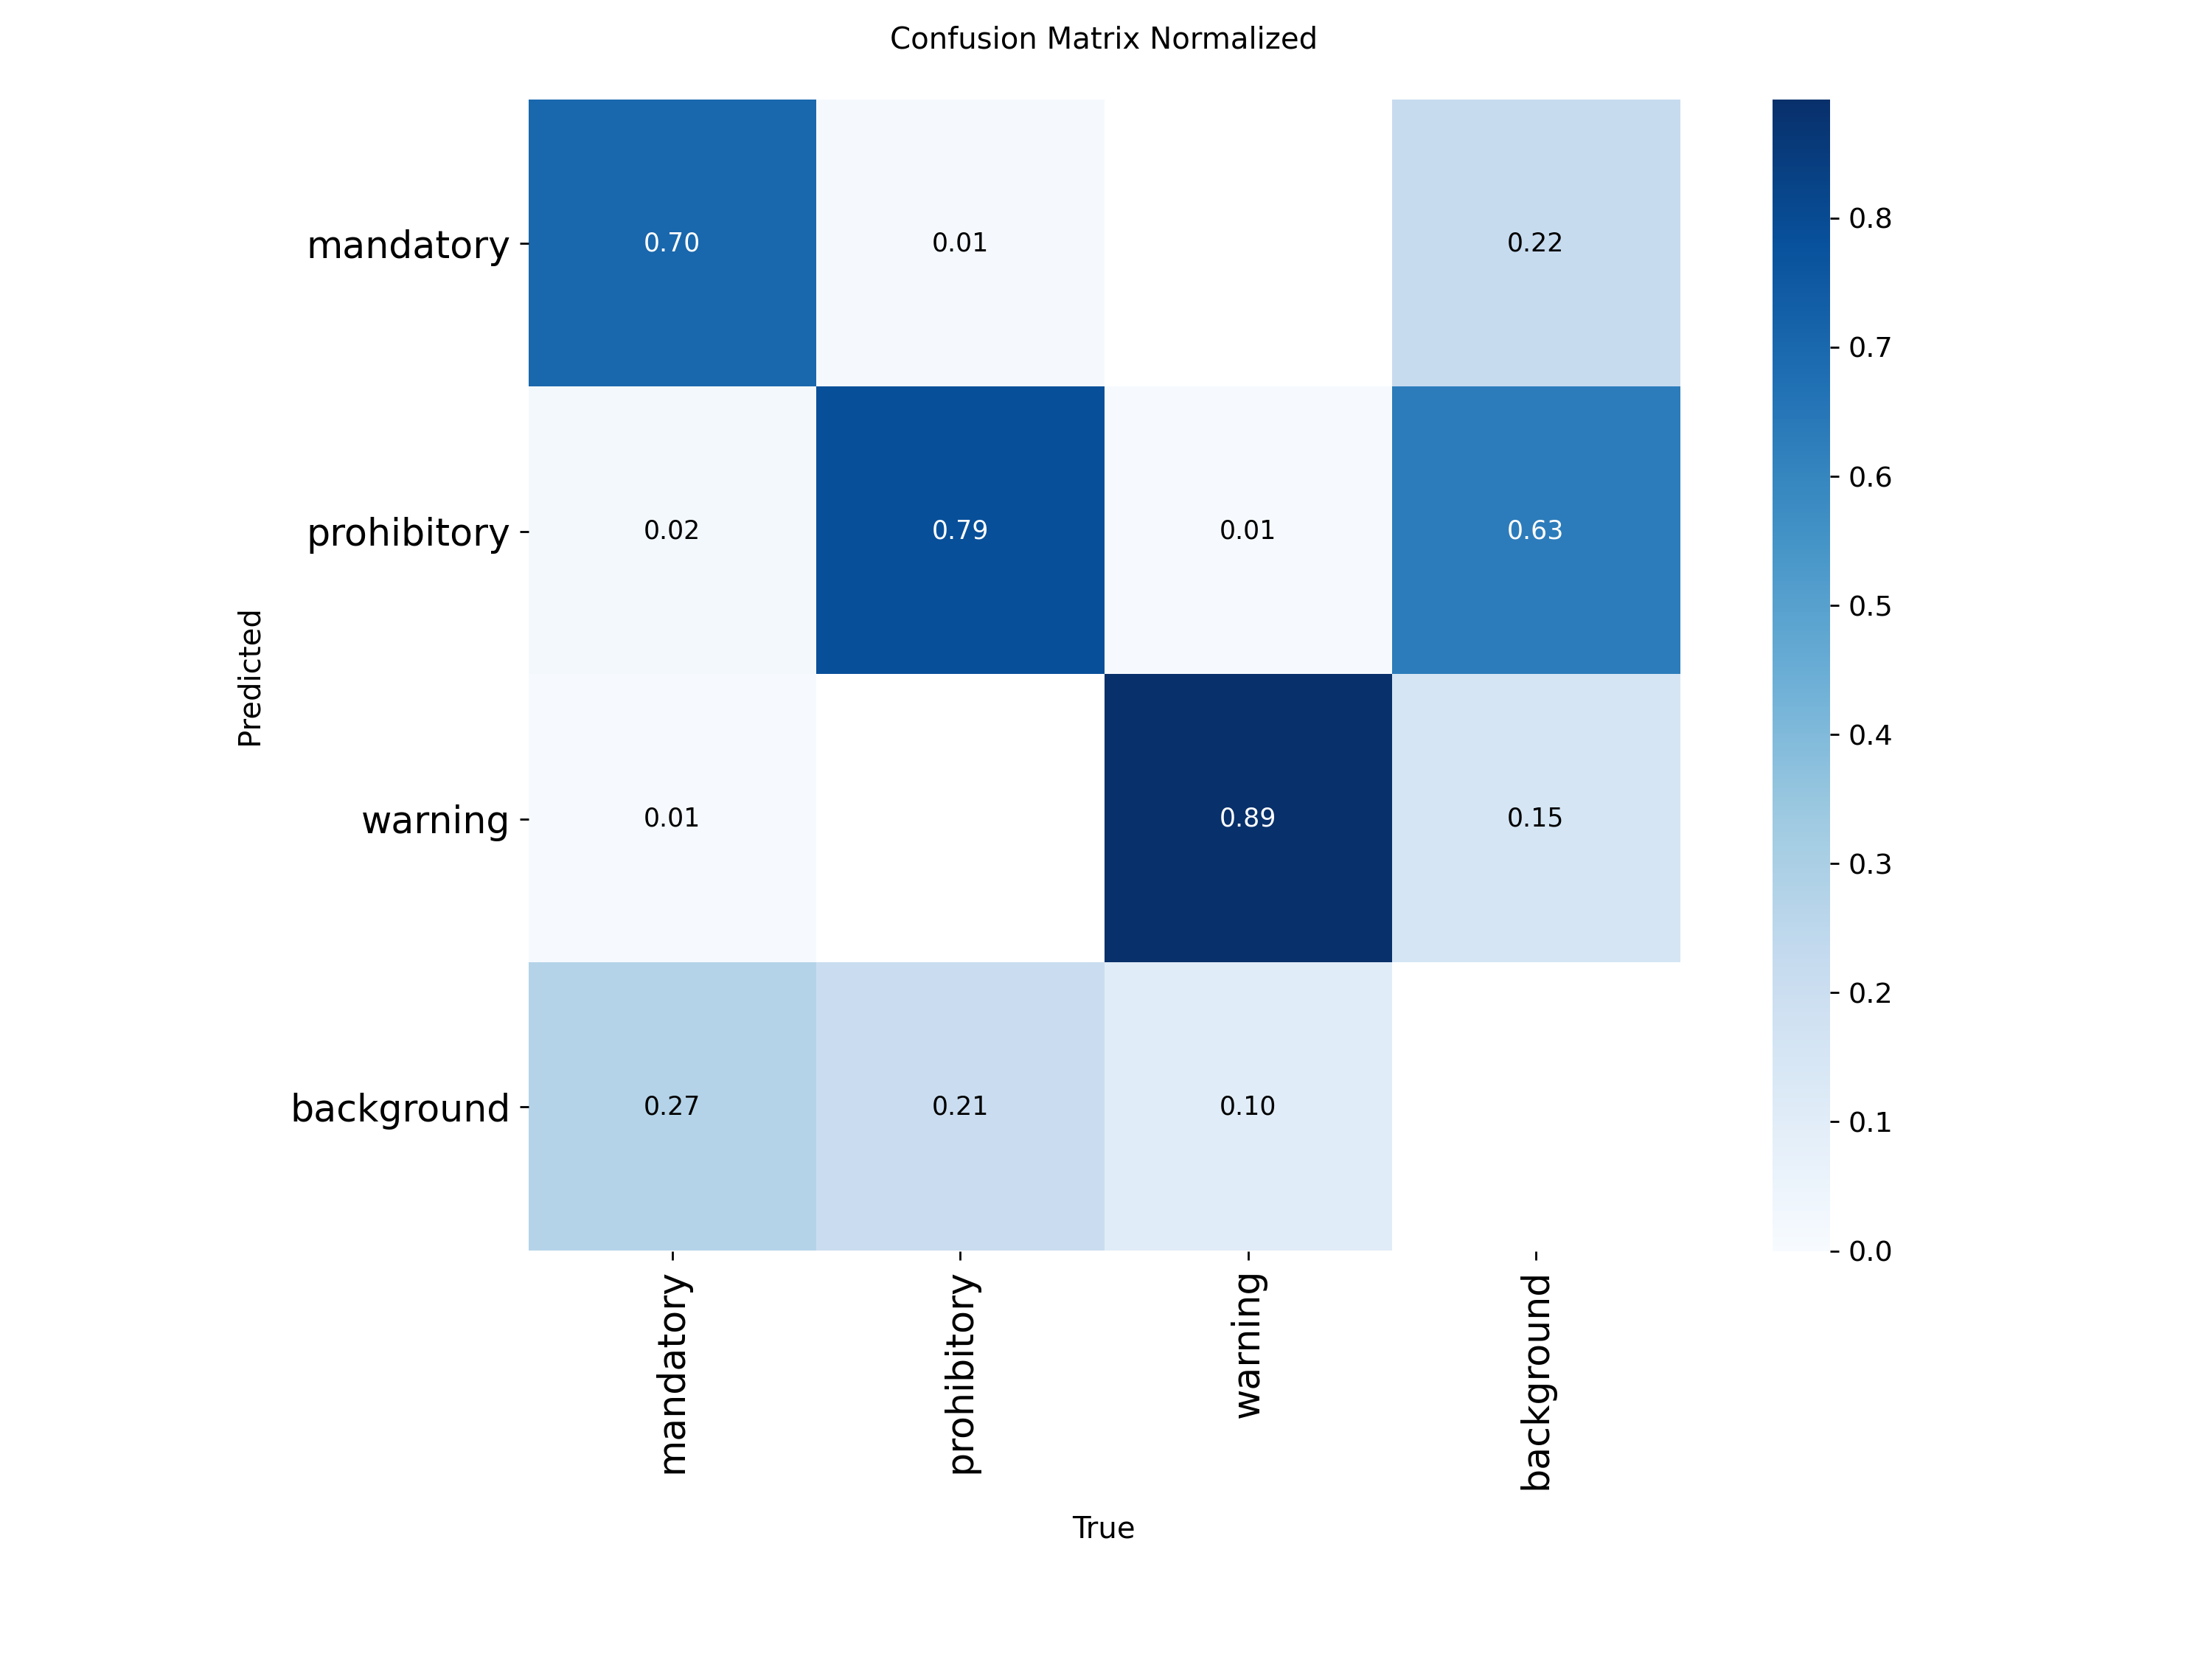

In [23]:
# ── Confusion matrices (saved by Ultralytics during val with plots=True) ─────
from IPython.display import Image, display

def show_image(path, title=""):
    if os.path.exists(path):
        print(f"\n{title}")
        display(Image(filename=path, width=700))
    else:
        print(f"[WARNING] Not found: {path}")

show_image(f"{output_path}/{model_name}/train/confusion_matrix_normalized.png",
           f"Confusion Matrix — {model_name} (Test Set)")


## Visual Inspection on Test Images

In [24]:
import glob
import random
from PIL import Image as PILImage
import numpy as np

# ── Gather test images ───────────────────────────────────────────────────────
test_img_dir = os.path.join(dataset_path, "images", "test")
all_test_imgs = glob.glob(os.path.join(test_img_dir, "*.jpg")) + \
                glob.glob(os.path.join(test_img_dir, "*.png"))

random.seed(42)
sample_imgs = random.sample(all_test_imgs, min(8, len(all_test_imgs)))
print(f"Selected {len(sample_imgs)} test images for visual inspection.")


Selected 8 test images for visual inspection.


In [25]:
# ── Side-by-side predictions: Baseline | ES-YOLO ────────────────────────────

def predict_and_plot(imgs, model, model_name, n_cols=2, conf=0.25, save_path=None):
    n_imgs = len(imgs)
    n_rows = n_imgs

    fig, axes = plt.subplots(n_rows, n_cols * 2 + 1, figsize=(26, n_rows * 4))
    fig.suptitle(f"Visual Inspection — {model_name}", fontsize=15, fontweight='bold')

    # Column headers
    col_titles = ["Image", model_name, "Prediction"]

    for row_idx, img_path in enumerate(imgs):
        # Run predictions
        res = model.predict(img_path, conf=conf, imgsz=640, verbose=False)[0]

        orig_img   = PILImage.open(img_path).convert("RGB")
        plotted = PILImage.fromarray(res.plot()[:, :, ::-1])

        col_data = [orig_img, plotted]
        titles   = ["Original", model_name]

        for col_idx, (img_data, title) in enumerate(zip(col_data, titles)):
            ax = axes[row_idx, col_idx] if n_rows > 1 else axes[col_idx]
            ax.imshow(img_data)
            ax.axis('off')
            if row_idx == 0:
                ax.set_title(title, fontsize=12, fontweight='bold', pad=6)

        # Hide unused subplots if any
        for c in range(len(col_data), axes.shape[1] if n_rows > 1 else len(axes)):
            extra = axes[row_idx, c] if n_rows > 1 else axes[c]
            extra.axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()

predict_and_plot(
    sample_imgs, best_weights, model_name,
    conf=0.25,
    save_path=f"{output_path}/{model_name}/visual_inspection_comparison.png"
)


Saved → ./runs/detect/YOLOv8s Traffic Detection/YOLOv8s + Weighted Concat + Dysample/visual_inspection_comparison.png


<Figure size 2600x3200 with 40 Axes>

In [26]:
# ── Confidence score distribution on test set ───────────────────────────────

def collect_confidences(model, img_list, conf_thresh=0.01):
    confs = []
    for p in img_list:
        res = model.predict(p, conf=conf_thresh, imgsz=640, verbose=False)[0]
        if res.boxes is not None and len(res.boxes):
            confs.extend(res.boxes.conf.cpu().numpy().tolist())
    return confs

confs_model = collect_confidences(best_weights, all_test_imgs)

In [27]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5), sharey=False)
fig.suptitle("Detection Confidence Distribution — Test Set", fontsize=14, fontweight='bold')

axes.hist(confs_model, bins=40, color="#1f77b4", alpha=0.8, edgecolor='white')
axes.set_title(f"{model_name}  (n={len(confs_model)} detections)", fontsize=12)
axes.set_xlabel("Confidence Score")
axes.set_ylabel("Count")
axes.axvline(0.25, color='red', linestyle='--', linewidth=1.5, label='thresh=0.25')
axes.legend()
axes.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_path}/{model_name}/confidence_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → confidence_distribution.png")

<Figure size 1400x500 with 1 Axes>

Saved → confidence_distribution.png



PR Curve — YOLOv8s + Weighted Concat + Dysample (Test Set)


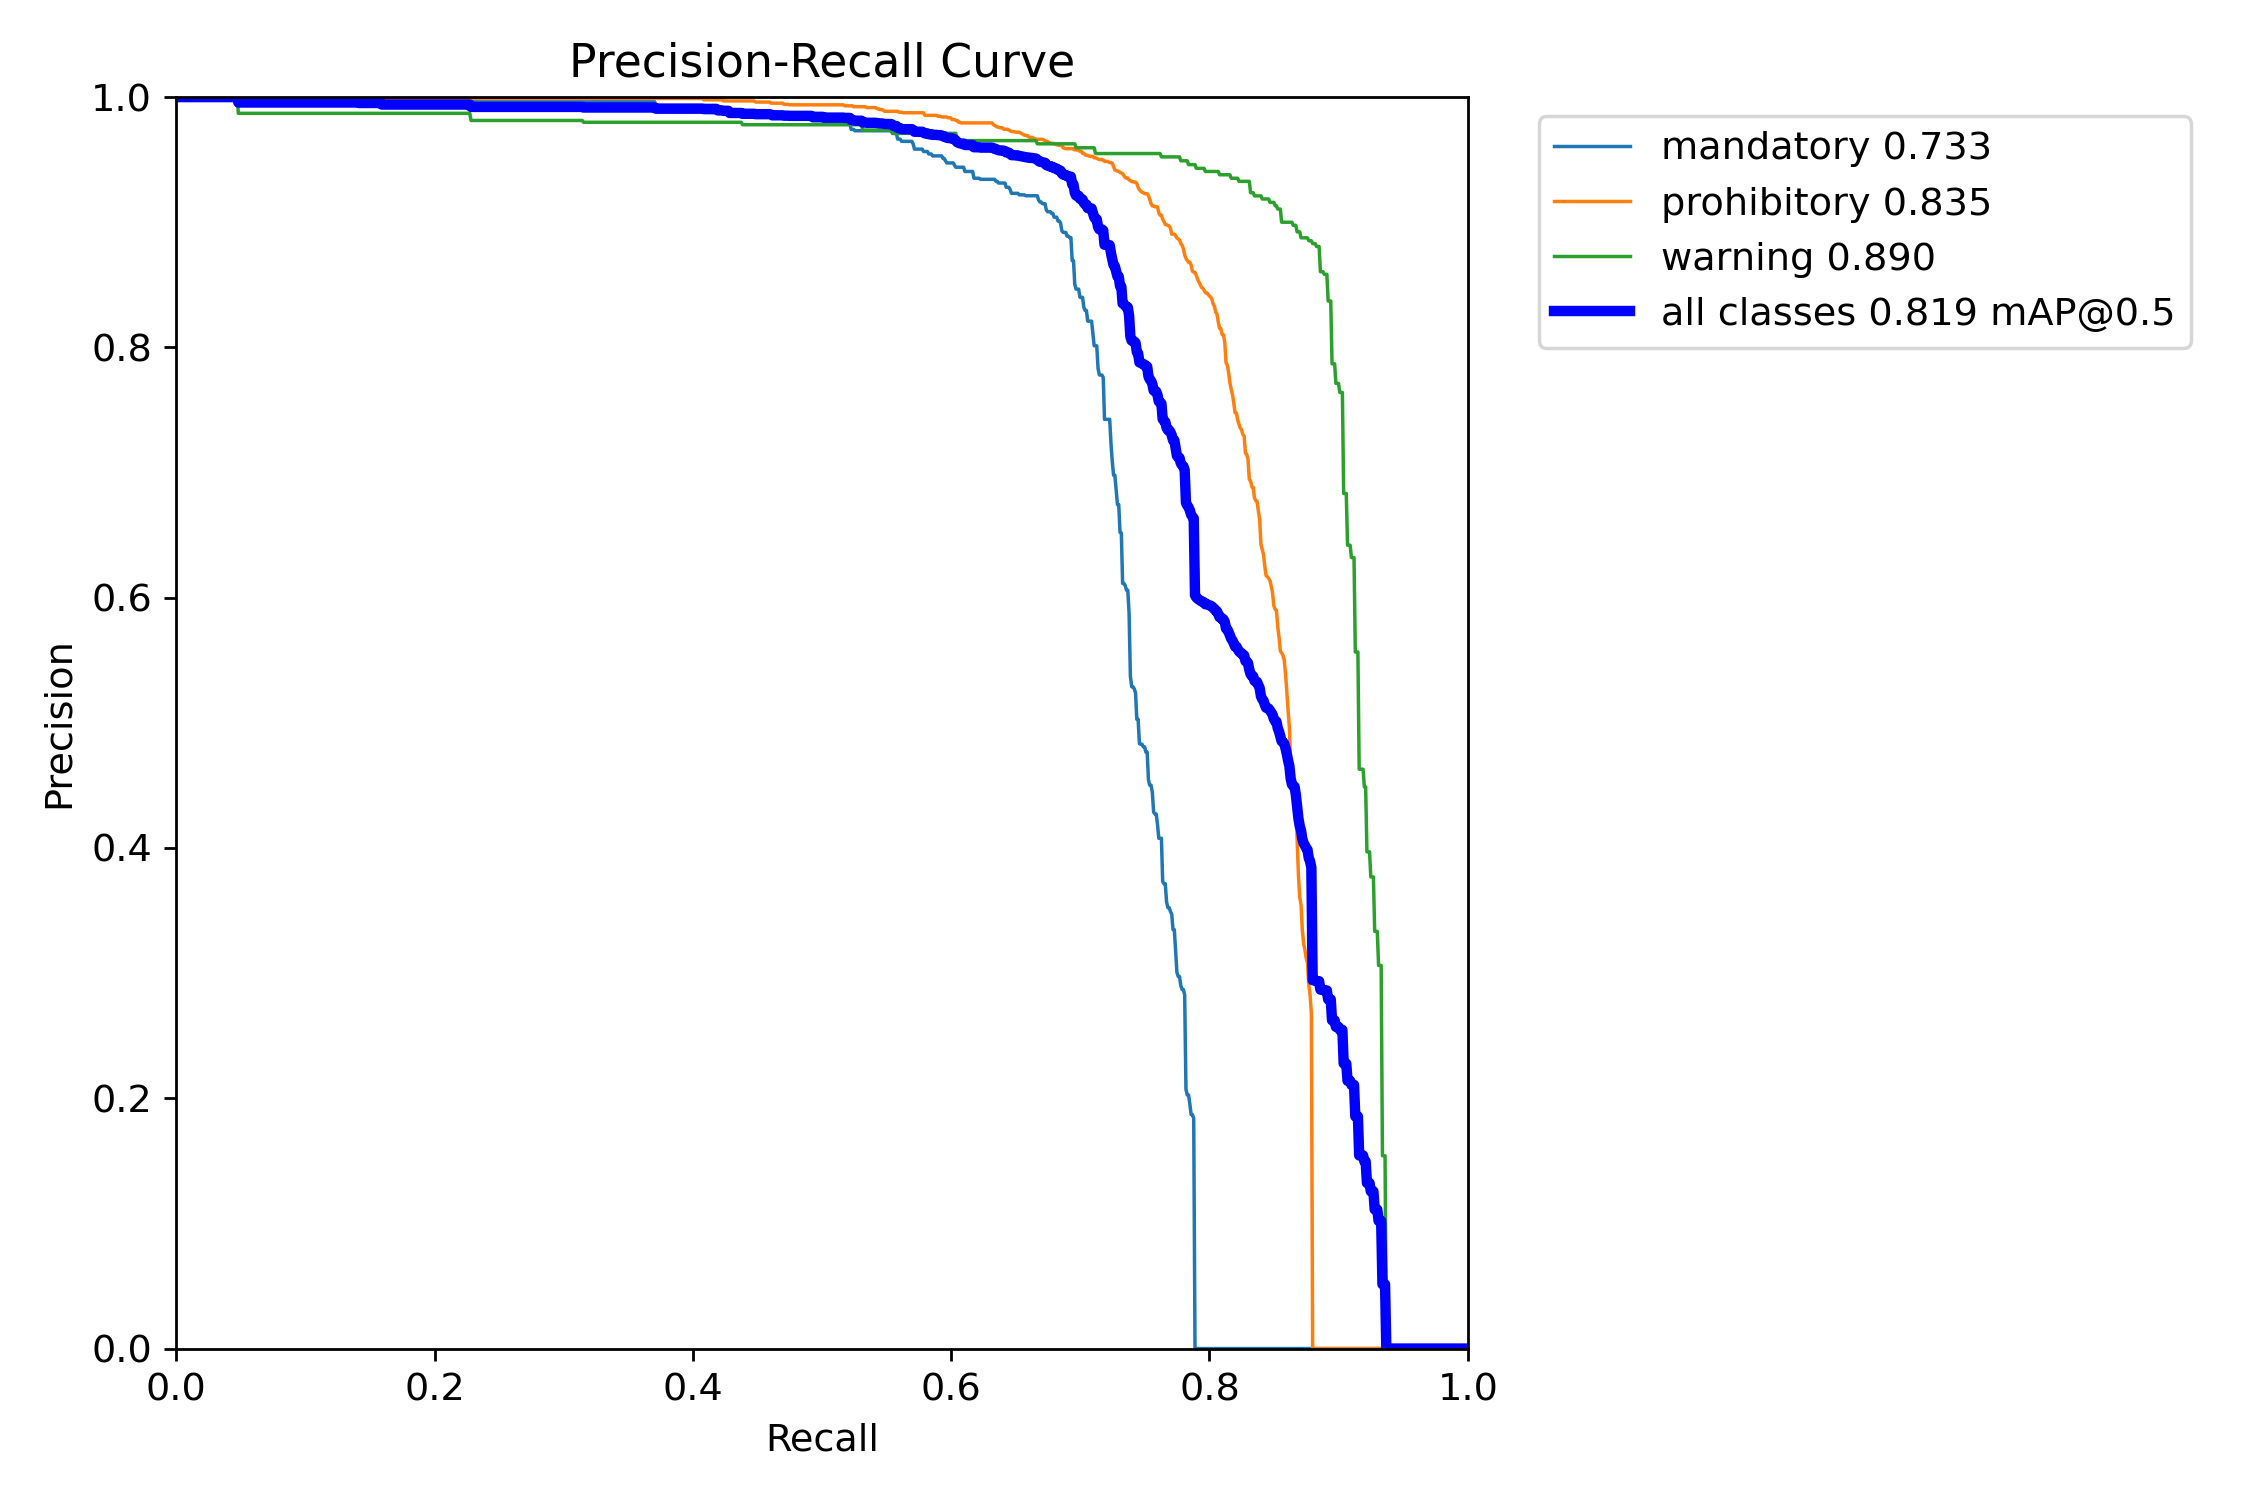

In [28]:
# ── Precision-Recall Curves (saved by Ultralytics) ──────────────────────────

show_image(f"{output_path}/{model_name}/train/BoxPR_curve.png",
           f"PR Curve — {model_name} (Test Set)")


F1-Confidence Curve — YOLOv8s + Weighted Concat + Dysample (Test Set)


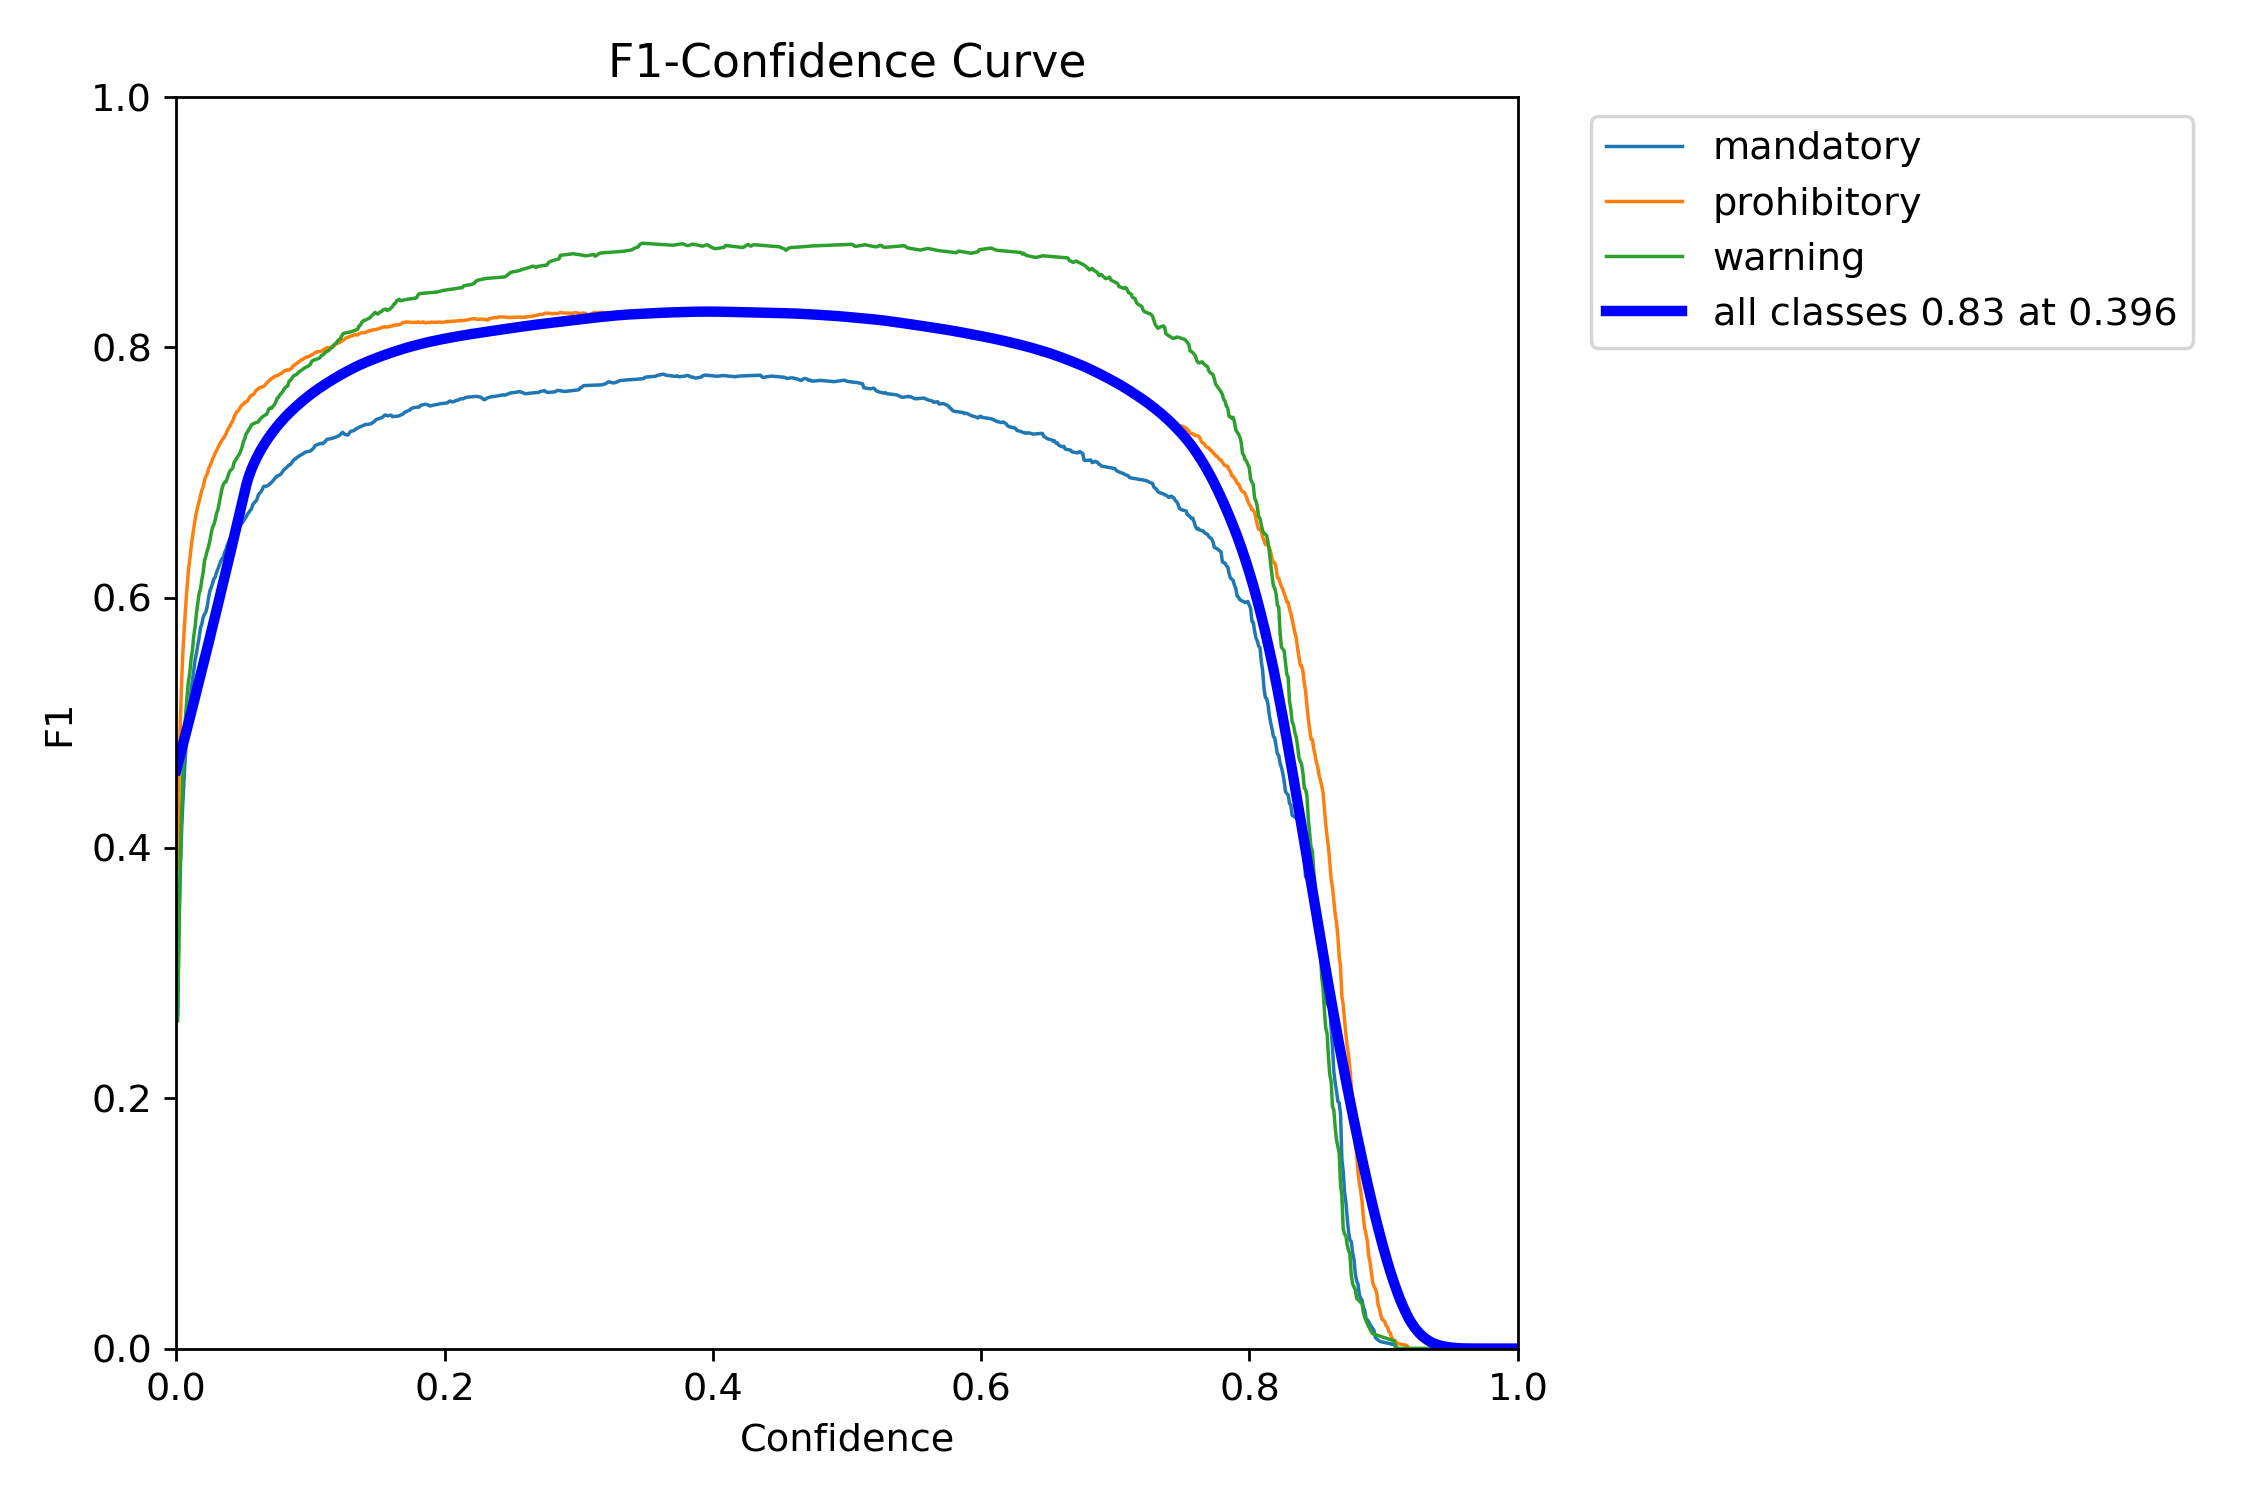

In [29]:
# ── F1 Curves (saved by Ultralytics) ─────────────────────────────────────────

show_image(f"{output_path}/{model_name}/train/BoxF1_curve.png",
           f"F1-Confidence Curve — {model_name} (Test Set)")


## Final Summary

In [30]:
# ── Summary comparison table ─────────────────────────────────────────────────
import pandas as pd
from IPython.display import display

summary = pd.DataFrame({
    "Model":      [model_name],
    "Precision":  [val_model.box.mp],
    "Recall":     [val_model.box.mr],
    "mAP@50":     [val_model.box.map50],
    "mAP@50-95":  [val_model.box.map],
}).set_index("Model").round(4)

# Highlight best value per column
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #d4edda; font-weight: bold; color:#000000' if v else '' for v in is_max]

print("\n===== Test Set Performance Summary =====")
display(summary.style.apply(highlight_max, axis=0))


===== Test Set Performance Summary =====


,Precision,Recall,mAP@50,mAP@50-95
Model,,,,
YOLOv8s + Weighted Concat + Dysample,0.899600,0.772600,0.819600,0.532100
